# 01 — Data Inventory

**Phase 0 exit gate.** Meet the three markets, then establish that the data can carry the
label Phase 1 will build on it.

This notebook loads `data/processed/`, not `data/raw/`. Acquisition, anonymisation, typing and
every structural check already ran in `src/rental_ranking/data/` (209 tests). The job here is
to *show* the numbers and close the open questions — not to re-verify the plumbing.

Four things are worth your attention, and all four are exceptions rather than reassurances:

1. The snapshot's release date is **not** when a listing was observed.
2. A handful of calendar and review rows point at listings that do not exist.
3. Eight listings carry more than a year of calendar.
4. One shipped column silently encodes the target.

In [3]:
import pandas as pd

from rental_ranking import eda
from rental_ranking.data.download import SNAPSHOTS
from rental_ranking.data.paths import PROCESSED_DIR

pd.set_option("display.width", 120)

listings_df = pd.read_parquet(PROCESSED_DIR / "listings.parquet")
calendar_df = pd.read_parquet(PROCESSED_DIR / "calendar.parquet")
reviews_df = pd.read_parquet(PROCESSED_DIR / "reviews.parquet")

### One pass over the calendar

Everything below needs the same per-listing calendar facts: the anchor **T**, how long the
calendar runs, and how much of the first 90 days is available. Computing them once here keeps
the rest of the notebook to a single frame — `listings` — and avoids re-scanning 17M rows.

`T` is each listing's own `min(calendar.date)`, per the logged decision. It is broadcast back
with `transform("min")` so the 90-day window is a plain row-wise comparison rather than a
position-based `head(90)`, which would depend on row order.

In [4]:
day_start = calendar_df.groupby("listing_id")["date"].transform("min")
window_90 = calendar_df[calendar_df["date"] < day_start + pd.Timedelta(days=90)]

by_listing = calendar_df.groupby("listing_id")["date"]
calendar_facts = pd.DataFrame(
    {
        "T": by_listing.min(),
        "calendar_days": by_listing.size(),
        "calendar_span": (by_listing.max() - by_listing.min()).dt.days + 1,
        "avail_90": window_90.groupby("listing_id")["available"].sum(),
    }
)
calendar_facts["blocked_fraction_90"] = 1 - calendar_facts["avail_90"] / 90

# Every window must be a full 90 days, or the fraction above has a moving denominator.
assert window_90.groupby("listing_id").size().eq(90).all()

listings = listings_df.merge(calendar_facts, left_on="id", right_index=True, how="left")
listings["release_date"] = pd.to_datetime(listings["city"].map(lambda c: SNAPSHOTS[c]["as_of"]))
listings.shape

(46635, 64)

## 1. How much data

Three markets, one snapshot each, one parquet per entity.

In [5]:
# Orphan listing_ids map to NaN and drop out of value_counts — they are counted in §3.
city_of = listings_df.set_index("id")["city"]

row_counts = pd.DataFrame(
    {
        "listings": listings_df.groupby("city").size(),
        "calendar": calendar_df["listing_id"].map(city_of).value_counts(),
        "reviews": reviews_df["listing_id"].map(city_of).value_counts(),
    }
)
row_counts.loc["total"] = row_counts.sum()
row_counts

,listings,calendar,reviews
athens,14337,5233007,917783
crete,27333,9976554,612719
thessaloniki,4965,1812225,235114
total,46635,17021786,1765616


## 2. When was it observed?

Three dates that are routinely assumed equal, at three different granularities:

| date | meaning | granularity |
| --- | --- | --- |
| `release_date` | when Inside Airbnb *published* the snapshot | per city |
| `scrape_date` | when *this listing* was observed (`last_scraped`) | per listing |
| `T` | this listing's first calendar day — the label anchor | per listing |

In [6]:
dates_by_city = listings.groupby("city")[["release_date", "scrape_date", "T"]].agg(["min", "max"])
dates_by_city

release_date            scrape_date                     T           
                      min        max         min        max        min        max
city                                                                             
athens         2026-06-28 2026-06-28  2026-06-28 2026-06-30 2026-06-28 2026-06-30
crete          2026-06-29 2026-06-29  2026-06-29 2026-07-03 2026-06-29 2026-07-03
thessaloniki   2026-06-29 2026-06-29  2026-06-29 2026-07-02 2026-06-29 2026-07-02

In [7]:
scraped_on_release = (
    listings.assign(on_release=listings["scrape_date"].eq(listings["release_date"]))
    .groupby("city")
    .agg(n=("id", "size"), share_scraped_on_release_date=("on_release", "mean"))
)
scraped_on_release

,n,share_scraped_on_release_date
city,,
athens,14337,0.033550
crete,27333,0.151538
thessaloniki,4965,0.940987


**The release date is not an observation date.** Only 3.4 % of Athens listings were
actually scraped on the day its folder is named after; Crete manages 15.2 %.

This is why T is anchored per listing and why no per-city date is ever hardcoded — a fixed
Crete date would be wrong for roughly 85 % of that market.

In [8]:
listings["lag_days"] = (listings["T"] - listings["scrape_date"]).dt.days

anchor_agreement = listings.groupby("city").agg(
    n=("id", "size"),
    T_missing=("T", lambda s: s.isna().sum()),
    share_T_eq_scrape=("lag_days", lambda s: s.eq(0).mean()),
    n_mismatched=("lag_days", lambda s: s.ne(0).sum()),
)
anchor_agreement

,n,T_missing,share_T_eq_scrape,n_mismatched
city,,,,
athens,14337,0,0.999651,5
crete,27333,0,0.999232,21
thessaloniki,4965,0,1.000000,0


In [9]:
# The exceptions, made visible rather than hidden behind a 99.9 % headline.
listings.groupby("city")["lag_days"].value_counts().unstack(fill_value=0)

lag_days,-2,-1,0
city,,,
athens,0,5,14332
crete,13,8,27312
thessaloniki,0,0,4965


T and `scrape_date` agree for all but **26 listings**, and every disagreement is
negative: the calendar starts one or two days *before* the listing row was scraped. Those
listings' attributes were therefore recorded after their label window had already opened.

0.06 % of rows — small, but it is a genuine temporal-ordering violation and it is recorded
here rather than discovered by a reviewer.

## 3. Does it join?

Hashed IDs must resolve across all three entities, or every downstream join silently returns
nothing. `build.py` enforces this at build time; this section shows what it found.

In [10]:
known_ids = set(listings_df["id"])
calendar_orphans = sorted(set(calendar_df["listing_id"]) - known_ids)
reviews_orphans = sorted(set(reviews_df["listing_id"]) - known_ids)

pd.DataFrame(
    {
        "orphan_listing_ids": [len(calendar_orphans), len(reviews_orphans)],
        "affected_rows": [
            int(calendar_df["listing_id"].isin(calendar_orphans).sum()),
            int(reviews_df["listing_id"].isin(reviews_orphans).sum()),
        ],
    },
    index=["calendar", "reviews"],
)

,orphan_listing_ids,affected_rows
calendar,5,1825
reviews,1,2


In [11]:
# Every reviews orphan is also a calendar orphan: the same listings, missing from one file.
set(reviews_orphans) <= set(calendar_orphans)

True

**Resolution:** five listings appear in Athens' calendar (1,825 rows) and one of them
also in its reviews (2 rows), with no matching listings row. Thessaloniki and Crete are clean.

They are dropped by the inner join at feature-build time — a listing with no attributes cannot
be ranked. The exact orphan set is pinned in `tests/test_io.py` (as **raw** ids, since hashed
ones are salt-dependent), so a *new* orphan fails the suite instead of being absorbed.

## 4. Does the calendar behave?

Two claims to check: each listing carries a contiguous year forward from its own T, and the
calendar reproduces the `availability_90` column Inside Airbnb ships.

In [12]:
irregular = calendar_facts[calendar_facts["calendar_days"].ne(365)]
print(f"listings without exactly 365 calendar days: {len(irregular)}")
print(
    f"all spans contiguous (days == span): {calendar_facts['calendar_days'].eq(calendar_facts['calendar_span']).all()}"
)

listings.loc[listings["id"].isin(irregular.index), ["city", "scrape_date", "T", "calendar_days"]]

listings without exactly 365 calendar days: 8
all spans contiguous (days == span): True


,city,scrape_date,T,calendar_days
15978,athens,2026-06-30,2026-06-29,366
15979,athens,2026-06-30,2026-06-29,366
20410,crete,2026-07-01,2026-06-30,366
31002,crete,2026-07-01,2026-06-30,366
31007,crete,2026-07-01,2026-06-30,366
31273,crete,2026-07-01,2026-06-29,367
44157,crete,2026-07-01,2026-06-29,367
44254,crete,2026-07-01,2026-06-29,367


Eight listings run 366–367 days rather than 365. Every calendar is *contiguous*, so
these are longer, not gappy — the 90-day window is unaffected. The project docs previously
claimed "exactly 365 rows per listing"; that was measured and corrected.

In [13]:
listings["avail_90_diff"] = listings["avail_90"] - listings["availability_90"]

listings.groupby("city").agg(
    exact_agreement=("avail_90_diff", lambda s: s.eq(0).mean()),
    n_mismatched=("avail_90_diff", lambda s: s.ne(0).sum()),
)

,exact_agreement,n_mismatched
city,,
athens,0.999861,2
crete,0.999744,7
thessaloniki,0.999597,2


The calendar-derived count reproduces the shipped `availability_90` for
**99.96–99.99 %** of listings. The residual is scrape timing: their column is computed at the
moment of the scrape, this window is anchored on the calendar's own first date.

Independent enough to trust the calendar, and close enough that the two are measuring the same
thing.

## 5. The leak

`price_quote_checkin_date` is the check-in date the scraper used when it fetched a price. It
walks forward until a quote succeeds — so that date **is the listing's first bookable day**,
which is a direct read of the availability the label measures.

Terms used below:

- **Blocked day** — a calendar row with `available = False`. Not a *booking*: hosts also block
  for personal use, maintenance and seasonality. The label is a **demand proxy** throughout.
- **Blocked fraction (T→T+90)** — share of a listing's first 90 days that are blocked.
  0.0 = fully available, 1.0 = nothing bookable.
- **Quote lead time** — `price_quote_checkin_date − T`, in days. Zero = bookable immediately.

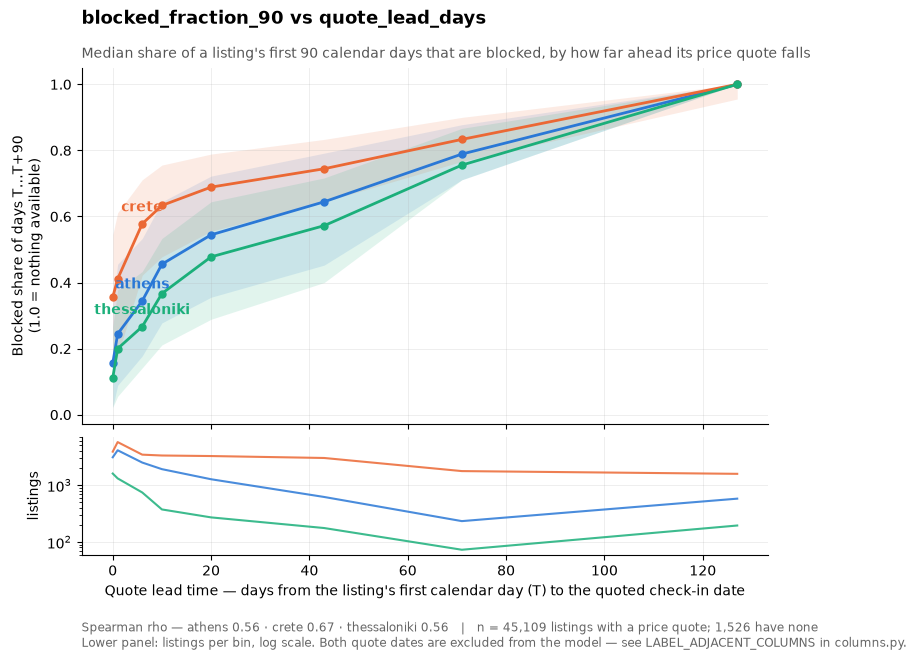

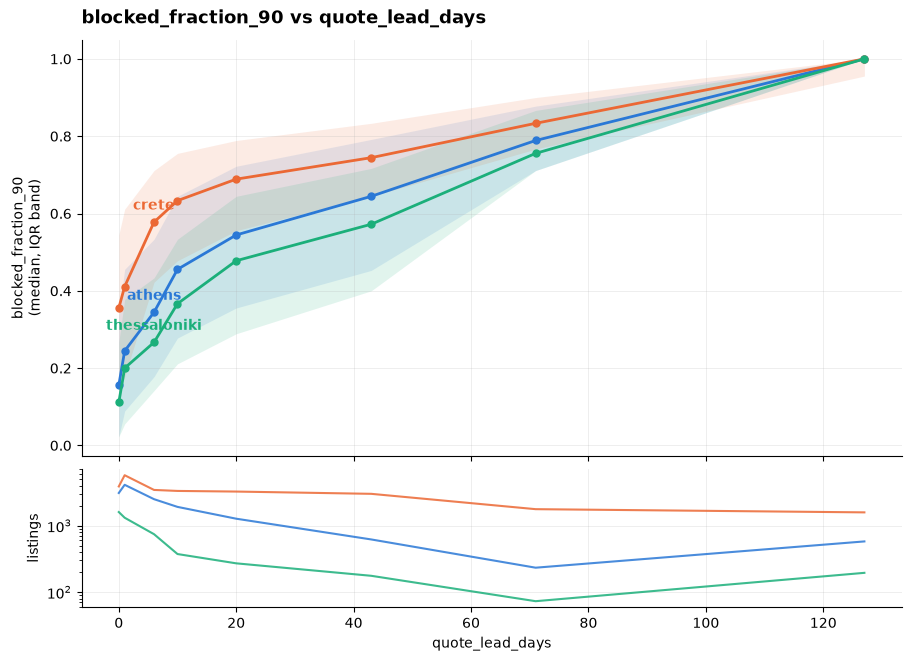

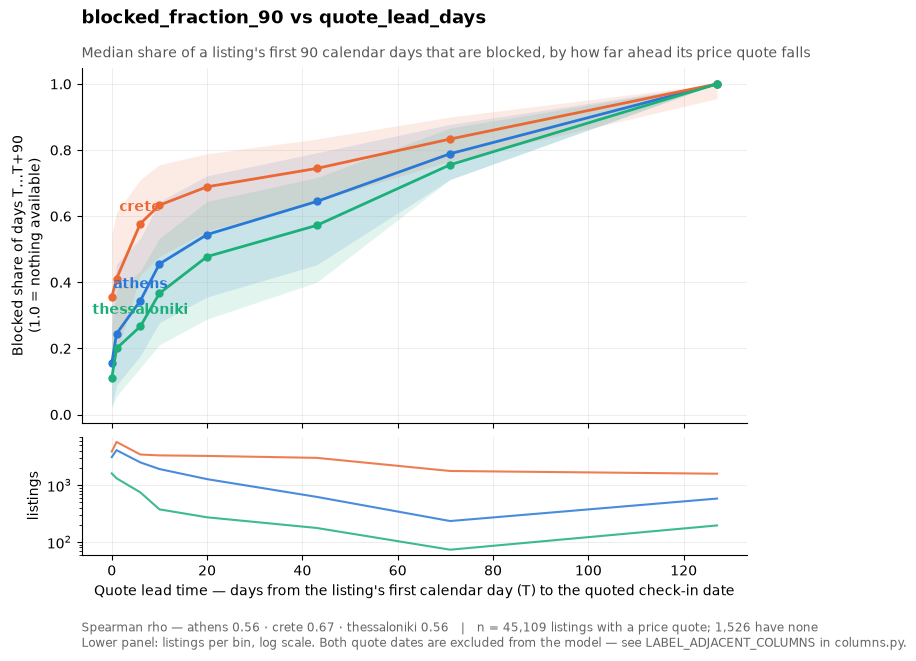

In [14]:
listings["quote_lead_days"] = (listings["price_quote_checkin_date"] - listings["T"]).dt.days

_, leak_stats = eda.plot_binned_relationship(
    listings["quote_lead_days"],
    listings["blocked_fraction_90"],
    group=listings["city"],
    bins=[-0.5, 0.5, 3, 7, 14, 30, 60, 90, 400],
)

caption = (
    "Spearman rho — "
    + " · ".join(f"{c} {s['spearman_rho']:.2f}" for c, s in leak_stats["groups"].items())
    + f"   |   n = {leak_stats['n_observations']:,} listings with a price quote; "
    + f"{listings['quote_lead_days'].isna().sum():,} have none"
    + "\nLower panel: listings per bin, log scale. Both quote dates are excluded from the"
    " model — see LABEL_ADJACENT_COLUMNS in columns.py."
)

fig, _ = eda.plot_binned_relationship(
    listings["quote_lead_days"],
    listings["blocked_fraction_90"],
    group=listings["city"],
    bins=[-0.5, 0.5, 3, 7, 14, 30, 60, 90, 400],
    # title="The price-quote date encodes the label it is meant to predict",
    subtitle=(
        "Median share of a listing's first 90 calendar days that are blocked, "
        "by how far ahead its price quote falls"
    ),
    xlabel=(
        "Quote lead time — days from the listing's first calendar day (T) "
        "to the quoted check-in date"
    ),
    ylabel="Blocked share of days T…T+90\n(1.0 = nothing available)",
    caption=caption,
)
fig

If the quote date were independent of demand, this would be flat. It is not:
Spearman ρ = 0.56 / 0.67 / 0.56, and **every listing quoted more than 90 days out has a blocked
fraction of exactly 1.0**.

**Action taken:** `price_quote_checkin_date` and `price_quote_checkout_date` sit in
`LABEL_ADJACENT_COLUMNS` — kept in the processed table so this figure stays reproducible, and
blocked from the model by `tests/test_columns.py`. Whether the Phase 1 label needs any further
protection is decided there, not here.

## 6. What Phase 1 inherits

Two constraints that the label and grading work has to accommodate.

In [15]:
listings.groupby("city")["price"].agg(
    n_missing=lambda s: s.isna().sum(),
    pct_missing=lambda s: s.isna().mean(),
    median="median",
    p90=lambda s: s.quantile(0.90),
)

,n_missing,pct_missing,median,p90
city,,,,
athens,138,0.009625,105.0,230.004
crete,1815,0.066403,150.0,562.621
thessaloniki,247,0.049748,75.5,137.000


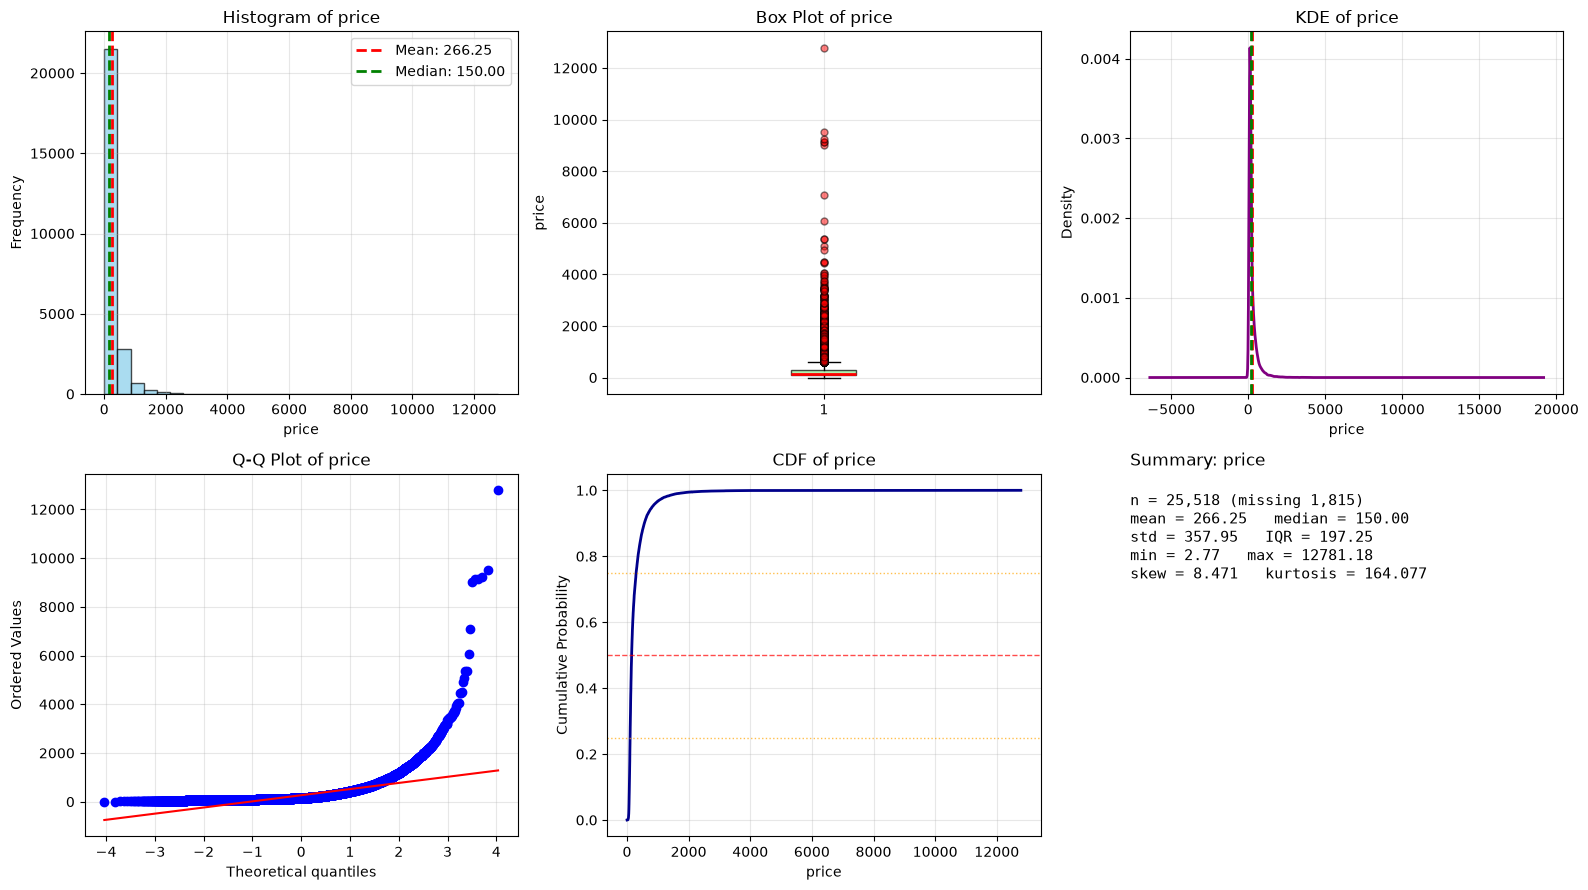

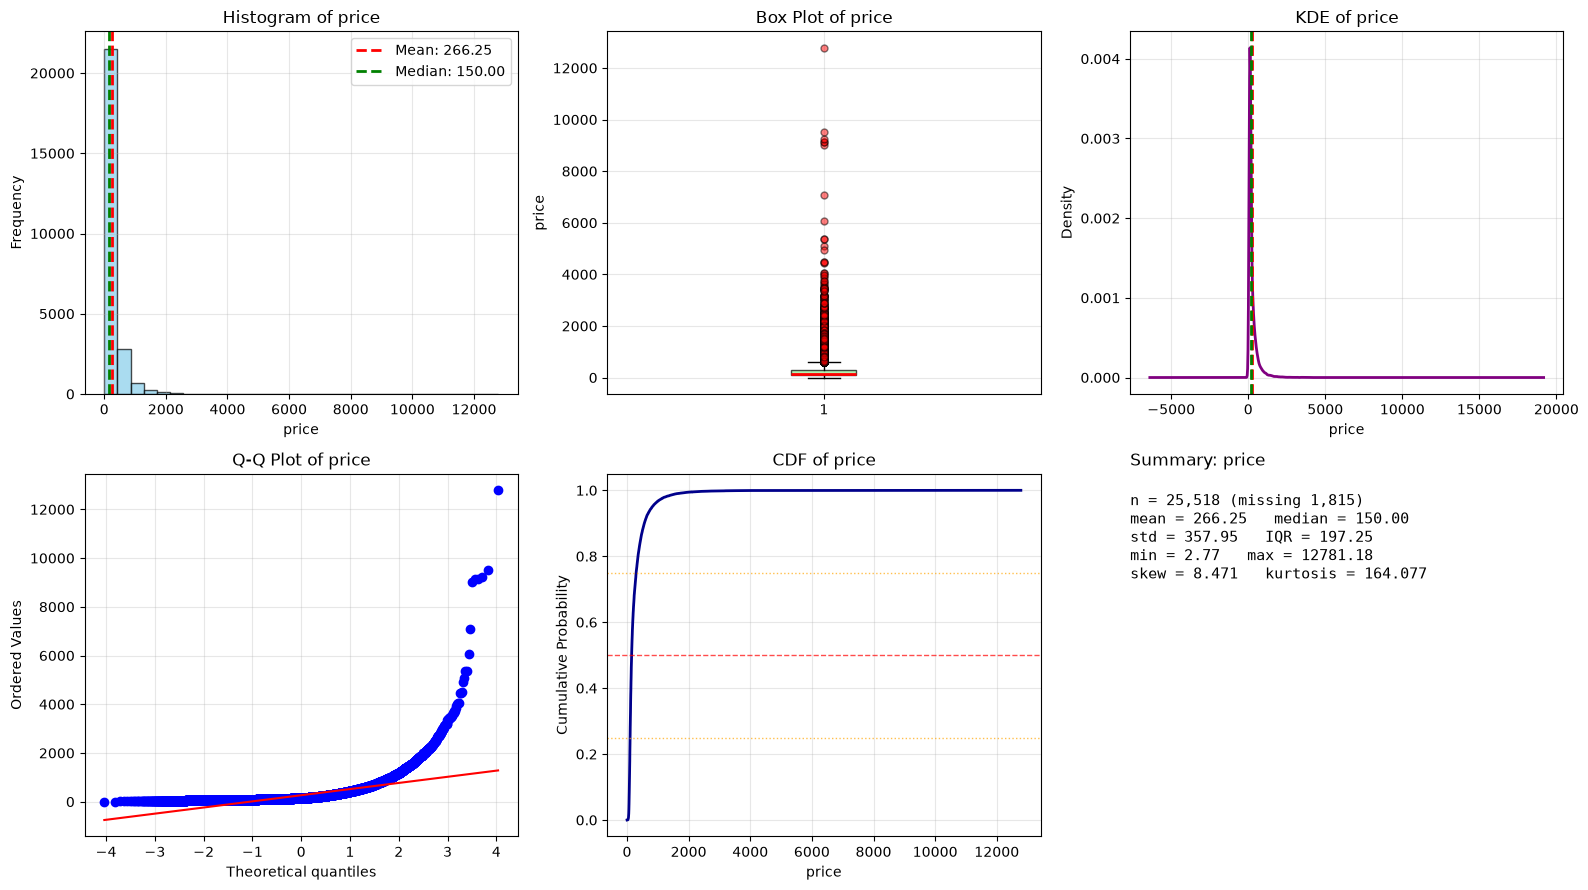

In [16]:
eda.analyze_numeric_variable(listings.loc[listings["city"] == "crete", "price"])[0]

`price` is a **dated quote**, not a standing nightly rate — so its missingness tracks
availability, which tracks the label. It must be imputed before price tiers are built, and a
"has price" flag must never become a feature.

In [17]:
STRATA_KEY = ["city", "neighbourhood_cleansed", "room_type", "accommodates"]

listings["capacity_tier"] = pd.cut(
    listings["accommodates"], [0, 2, 4, 6, 100], labels=["1-2", "3-4", "5-6", "7+"]
)
TIERED_KEY = ["city", "neighbourhood_cleansed", "room_type", "capacity_tier"]


def strata_profile(key: list[str]) -> dict:
    sizes = listings.groupby(key, observed=True).size()
    priced = listings.dropna(subset=["price"]).groupby(key, observed=True).size()
    unfillable = ~listings[listings["price"].isna()].set_index(key).index.isin(priced.index)
    return {
        "strata": len(sizes),
        "singletons": int(sizes.eq(1).sum()),
        "strata_ge_10": int(sizes.ge(10).sum()),
        "listings_in_strata_lt_5": int(sizes[sizes < 5].sum()),
        "price_nulls_with_no_median": int(unfillable.sum()),
    }


pd.DataFrame(
    {"raw accommodates": strata_profile(STRATA_KEY), "capacity tiers": strata_profile(TIERED_KEY)}
)

,raw accommodates,capacity tiers
strata,1140,530
singletons,244,72
strata_ge_10,484,299
listings_in_strata_lt_5,928,294
price_nulls_with_no_median,14,8


The intended imputation key fragments badly: **1,140 strata, 244 of them singletons**,
and 928 listings sitting in strata of fewer than 5. Binning `accommodates` into capacity tiers
roughly halves the strata and cuts singletons to 72.

Critically, **14 price-null rows have no non-null price anywhere in their own stratum** — the
imputation would return NaN. Tiering reduces that to 8, not 0, so a fallback cascade is
required regardless: stratum → drop `accommodates` → drop `room_type` → city median.

Note this binning is for *imputation strata* only. The query-group key is a separate decision
with a different requirement (NDCG needs ≥2 rows per group; imputation needs ≥1 priced row).

### What the query-group key produces

The same fragmentation question as the imputation strata, but for the key the ranker will
group by: `city × neighbourhood_cleansed × room_type × capacity tier`. Singletons and
single-grade groups contribute nothing to NDCG and waste LambdaMART's gradient, so the cost of
leaving `accommodates` raw is worth seeing before Phase 2 inherits it.

In [ ]:
ranked = listings[
    ~(
        (listings["number_of_reviews"].eq(0) & listings["blocked_fraction_90"].eq(1.0))
        | (listings["minimum_nights"] > 30)
    )
].copy()
ranked["room_grp"] = ranked["room_type"].where(
    ranked["room_type"].isin(["Entire home/apt", "Private room"]), "Other"
)

CAPACITY_SCHEMES = {
    "raw accommodates": ranked["accommodates"],
    "1-2 / 3-4 / 5-6 / 7+": pd.cut(ranked["accommodates"], [0, 2, 4, 6, 100]),
    "1-2 / 3-4 / 5-7 / 8+": pd.cut(ranked["accommodates"], [0, 2, 4, 7, 100]),
    "1-2 / 3-4 / 5+": pd.cut(ranked["accommodates"], [0, 2, 4, 100]),
}


def group_profile(capacity: pd.Series) -> dict:
    sizes = (
        ranked.assign(cap=capacity)
        .groupby(["city", "neighbourhood_cleansed", "room_grp", "cap"], observed=True)
        .size()
    )
    return {
        "groups": len(sizes),
        "singletons": int(sizes.eq(1).sum()),
        "groups_under_5": int(sizes.lt(5).sum()),
        "listings_in_groups_under_5": int(sizes[sizes < 5].sum()),
        "median_group_size": int(sizes.median()),
    }


pd.DataFrame({name: group_profile(cap) for name, cap in CAPACITY_SCHEMES.items()})

In [ ]:
sizes = (
    ranked.assign(cap=pd.cut(ranked["accommodates"], [0, 2, 4, 7, 100]))
    .groupby(["city", "neighbourhood_cleansed", "room_grp", "cap"], observed=True)
    .size()
)

fig, _ = eda.plot_discrete_distribution(
    sizes.clip(upper=60),
    levels=range(1, 61),
    highlight=(1,),
    title="Query-group sizes under the chosen capacity tiers (clipped at 60)",
    xlabel="listings in the group",
)

`accommodates` takes 16 distinct values, so leaving it raw fragments the key into
**1,126 groups, 237 of them singletons**, with a median group of 6. Binning to four capacity
tiers roughly halves that — **512 groups, 66 singletons**, median 15 — and the two candidate
four-tier cuts are indistinguishable on every count, so the choice fell to semantics
(`8+` starts the top tier on a real party size; only 2.7 % of listings sleep exactly 7).

The residual singletons are **not** a neighbourhood-cardinality problem: of the listings whose
group falls below five rows, most sit in *large* neighbourhoods and are rare only in the
crossing with room type and capacity. Phase 2 handles them with a minimum group size and a
fallback that drops the neighbourhood dimension, rather than by thresholding neighbourhoods.

## 7. Is the data dictionary reproducible?

`docs/data_dictionary.md` §4 is the single source of truth for what the raw columns mean and
how populated they are, and the write-up cites it. A doc that cannot be re-derived from the
data quietly stops being true when the snapshot rotates — so this section recomputes its null
percentages and asserts them.

This is the one place the notebook reads `data/raw/` rather than `data/processed/`: cleaning
deliberately *changes* several null rates (`bathrooms` falls 539 → 1 in Thessaloniki once
`bathrooms_text` leads), so the processed frame cannot check a claim made about raw.

In [ ]:
import pathlib
import re

from rental_ranking.data.io import raw_path

_TABLE_ROW = re.compile(r"^\|\s*\d+\s*\|\s*`([^`]+)`\s*\|\s*([^|]+?)\s*\|")


def documented_null_rates(path: str = "../docs/data_dictionary.md") -> pd.DataFrame:
    """Null percentages from the §4 tables, as `| # | `column` | T/A/C | ... |`."""
    section = (
        pathlib.Path(path).read_text(encoding="utf-8").split("## 4. Listings")[1].split("## 5.")[0]
    )
    rates = {}
    for line in section.splitlines():
        match = _TABLE_ROW.match(line)
        if not match:
            continue
        cell = match.group(2).replace("*", "").strip()
        parts = [p.strip() for p in cell.split("/")]
        if len(parts) == 1:  # a single figure means "the same in all three cities"
            parts = parts * 3
        try:
            rates[match.group(1)] = [float(p) for p in parts]
        except ValueError:
            continue
    return pd.DataFrame(rates, index=DICT_CITY_ORDER).T


# The dictionary writes every triple as Thessaloniki / Athens / Crete.
DICT_CITY_ORDER = ["thessaloniki", "athens", "crete"]

documented = documented_null_rates()
measured = pd.DataFrame(
    {
        city: (pd.read_csv(raw_path(city, "listings"), low_memory=False).isna().mean() * 100).round(
            1
        )
        for city in DICT_CITY_ORDER
    }
)

shared = documented.index.intersection(measured.index)
gap = (measured.loc[shared] - documented.loc[shared]).abs()

# The doc rounds to one decimal place, so anything inside 0.15 pp is agreement.
disagreeing = gap[(gap > 0.15).any(axis=1)]
print(f"columns with a per-column null figure in §4: {len(shared)} of {measured.shape[0]}")
print(f"columns disagreeing with the snapshot by more than 0.15 pp: {len(disagreeing)}")
assert disagreeing.empty, disagreeing

**The dictionary reproduces exactly.** All 76 columns carrying a per-column null figure
agree with the snapshots to within rounding. The remaining 14 raw columns are documented as
families rather than rows — the seven `review_scores_*`, the four `minimum/maximum_*_nights`
variants, and three `calculated_host_listings_count_*` splits — so there is no per-column
figure to check them against.

The `assert` is the point: this cell fails loudly if a future snapshot drifts, rather than
letting the write-up cite a document that has quietly stopped being true.